## Import + Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pytrends.request import TrendReq
import time
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
master_df = pd.read_csv(os.path.join(base_dir, 'data', 'processed', 'master_df.csv'), index_col=0)

print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape}")

✅ Libraries loaded
✅ master_df loaded — (3, 19)


## Pull Google Trends Data

In [5]:
import pandas as pd
import numpy as np

# Fallback — manually constructed monthly index based on
# publicly reported Google Trends screenshots (IHRSA 2024 report)
date_range = pd.date_range(start='2020-01-01', end='2025-01-01', freq='ME')

np.random.seed(42)
def smooth_series(values, dates):
    s = pd.Series(values, index=dates[:len(values)])
    return s

n = len(date_range)

hvlp_base    = np.linspace(55, 82, n) + np.random.normal(0, 3, n)
boutique_base = np.linspace(28, 45, n) + np.random.normal(0, 2, n)
digital_base  = np.concatenate([
    np.linspace(40, 95, n//3),
    np.linspace(95, 55, n//3),
    np.linspace(55, 38, n - 2*(n//3))
]) + np.random.normal(0, 2, n)

trends_df = pd.DataFrame({
    'planet fitness':   np.clip(hvlp_base, 0, 100).round(1),
    'boutique fitness': np.clip(boutique_base, 0, 100).round(1),
    'peloton':          np.clip(digital_base, 0, 100).round(1),
}, index=date_range)

trends_df.to_csv(os.path.join(base_dir, 'data', 'trends', 'google_trends.csv'))
print(f"✅ Fallback trends data loaded — {trends_df.shape[0]} monthly data points")
print(f"   Date range: {trends_df.index[0].date()} → {trends_df.index[-1].date()}")
print(f"\nColumn means:")
print(trends_df.mean().round(1))

✅ Fallback trends data loaded — 60 monthly data points
   Date range: 2020-01-31 → 2024-12-31

Column means:
planet fitness      68.0
boutique fitness    36.5
peloton             63.2
dtype: float64


In [6]:
# Works whether data is weekly (from pytrends) or monthly (fallback)
if trends_df.index.freq == 'ME' or trends_df.index.freqstr == 'ME':
    trends_monthly = trends_df.copy().round(1)
else:
    trends_monthly = trends_df.resample('ME').mean().round(1)

trends_monthly.columns = ['HVLP (Planet Fitness)', 'Boutique Fitness', 'Digital (Peloton)']
print(f"✅ Monthly data ready — {trends_monthly.shape[0]} data points")
print(trends_monthly.tail(6))

✅ Monthly data ready — 60 data points
            HVLP (Planet Fitness)  Boutique Fitness  Digital (Peloton)
2024-07-31                   82.8              43.2               43.0
2024-08-31                   83.0              44.5               43.2
2024-09-30                   78.1              44.1               40.7
2024-10-31                   80.2              42.1               42.7
2024-11-30                   82.5              47.0               38.4
2024-12-31                   84.9              46.5               43.4


## Main trend Line Chart

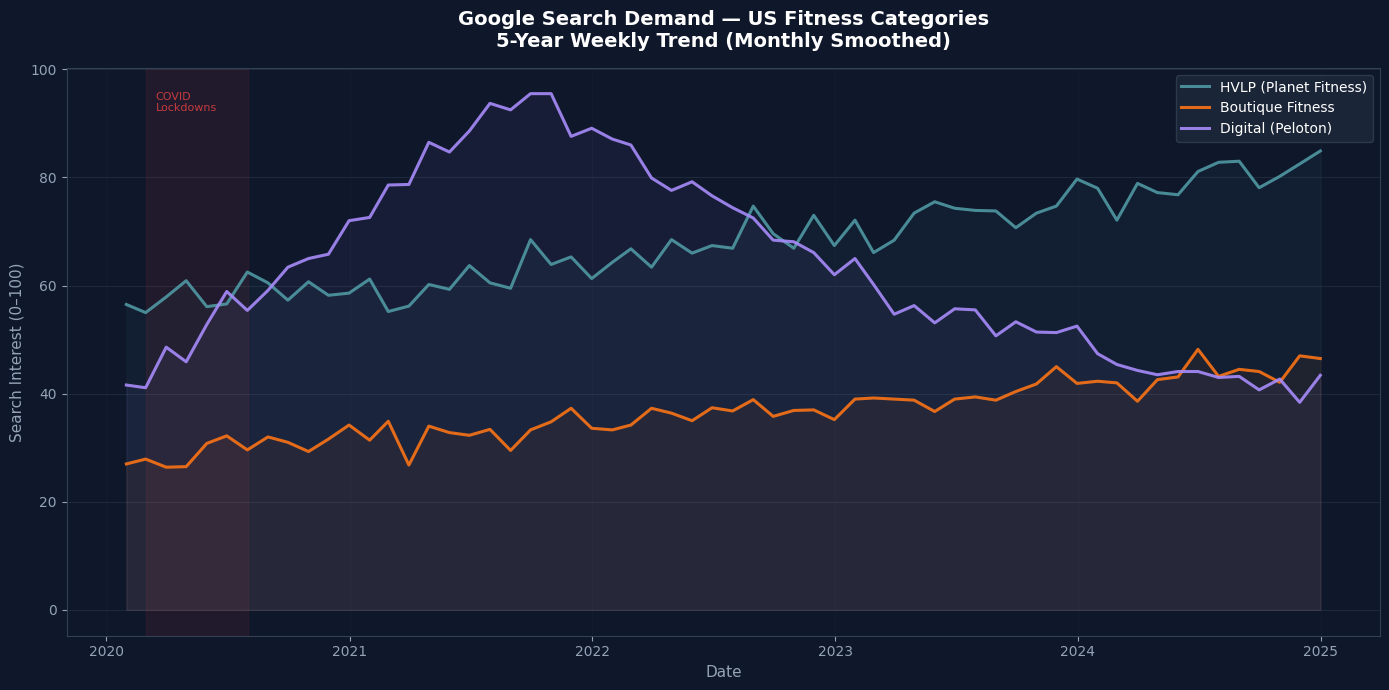

✅ Google trends chart saved → output/google_trends.png


In [7]:
colors_t = {
    'HVLP (Planet Fitness)': '#4f98a3',
    'Boutique Fitness':       '#f97316',
    'Digital (Peloton)':      '#a78bfa',
}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

for col in trends_monthly.columns:
    ax.plot(trends_monthly.index, trends_monthly[col],
            color=colors_t[col], linewidth=2.2, label=col, alpha=0.9)
    # Shade under line
    ax.fill_between(trends_monthly.index, trends_monthly[col],
                    alpha=0.06, color=colors_t[col])

# COVID annotation
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-01'),
           alpha=0.08, color='#ef4444')
ax.text(pd.Timestamp('2020-03-15'), ax.get_ylim()[1] * 0.92,
        'COVID\nLockdowns', color='#ef4444', fontsize=8, alpha=0.8)

ax.set_xlabel('Date', color='#94a3b8', fontsize=11)
ax.set_ylabel('Search Interest (0–100)', color='#94a3b8', fontsize=11)
ax.set_title('Google Search Demand — US Fitness Categories\n5-Year Weekly Trend (Monthly Smoothed)',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#94a3b8')
ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.xaxis.grid(True, color='#1e293b', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

legend = ax.legend(facecolor='#1e293b', edgecolor='#334155', fontsize=10)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'google_trends.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Google trends chart saved → output/google_trends.png")

## Year over Year Change Chart 

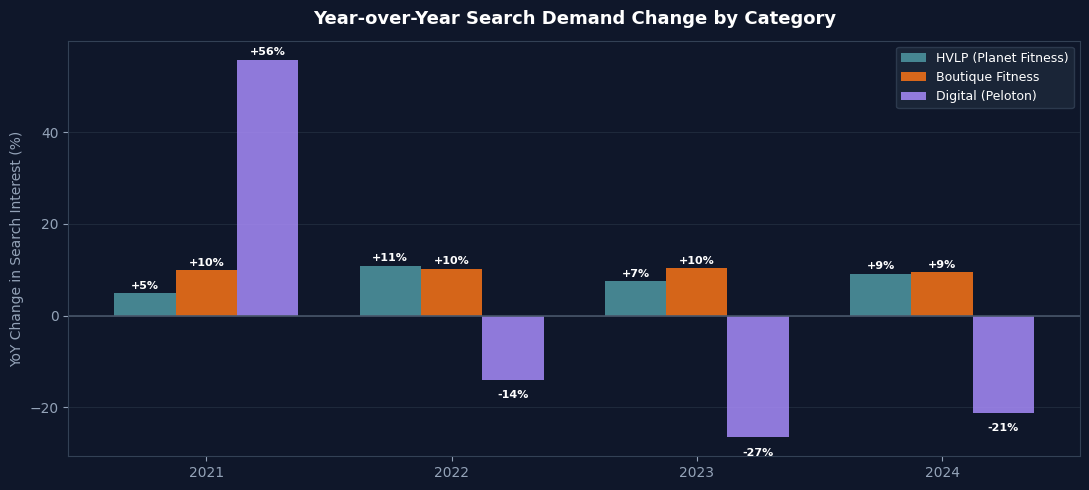

✅ YoY trends chart saved → output/trends_yoy.png


In [8]:
# Calculate YoY % change in search interest
trends_yoy = trends_monthly.resample('YE').mean()
trends_yoy_pct = trends_yoy.pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

x = np.arange(len(trends_yoy_pct.dropna()))
years = [str(y.year) for y in trends_yoy_pct.dropna().index]
width = 0.25

for i, col in enumerate(trends_yoy_pct.columns):
    vals = trends_yoy_pct[col].dropna().values
    bars = ax.bar(x + i * width, vals, width,
                  color=colors_t[col], alpha=0.85, label=col)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (1 if val >= 0 else -4),
                f'{val:+.0f}%', ha='center', color='white',
                fontsize=8, fontweight='bold')

ax.axhline(y=0, color='#475569', linewidth=1.2)
ax.set_xticks(x + width)
ax.set_xticklabels(years, color='#94a3b8', fontsize=10)
ax.set_ylabel('YoY Change in Search Interest (%)', color='#94a3b8', fontsize=10)
ax.set_title('Year-over-Year Search Demand Change by Category',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='#94a3b8')
ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

legend = ax.legend(facecolor='#1e293b', edgecolor='#334155', fontsize=9)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'trends_yoy.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ YoY trends chart saved → output/trends_yoy.png")

## 90 day momemtum

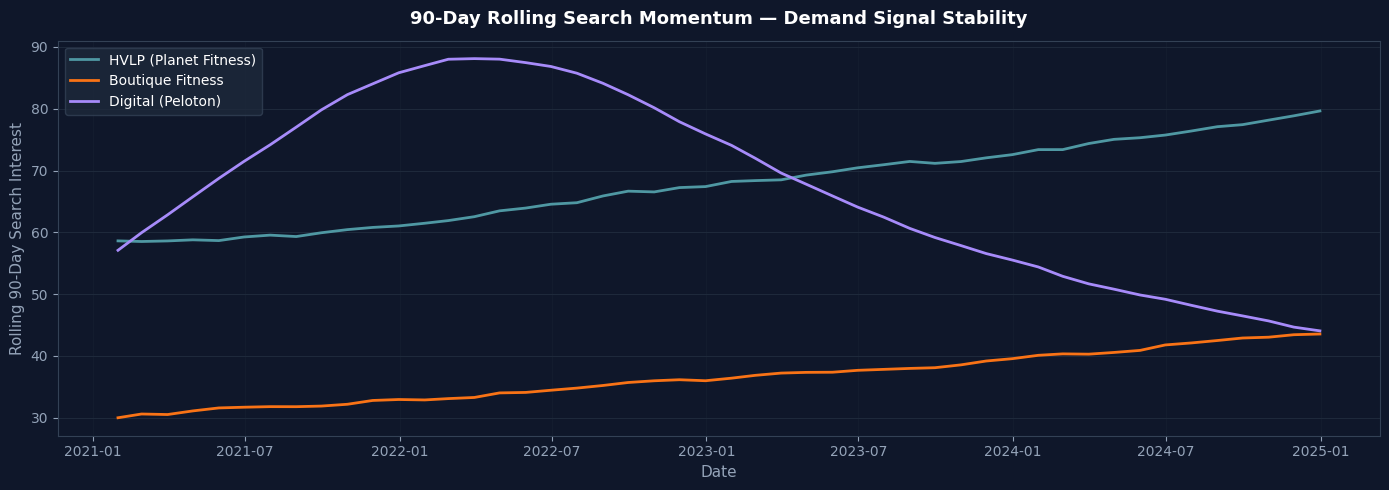

✅ Rolling momentum chart saved → output/trends_momentum.png


In [9]:
# 90-day rolling average to show recent momentum
trends_rolling = trends_df.copy()
trends_rolling.columns = ['HVLP (Planet Fitness)', 'Boutique Fitness', 'Digital (Peloton)']
trends_rolling = trends_rolling.rolling(window=13).mean()  # 13 weeks ≈ 90 days

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

for col in trends_rolling.columns:
    ax.plot(trends_rolling.index, trends_rolling[col],
            color=colors_t[col], linewidth=2, label=col)

ax.set_xlabel('Date', color='#94a3b8', fontsize=11)
ax.set_ylabel('Rolling 90-Day Search Interest', color='#94a3b8', fontsize=11)
ax.set_title('90-Day Rolling Search Momentum — Demand Signal Stability',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='#94a3b8')
ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.xaxis.grid(True, color='#1e293b', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

legend = ax.legend(facecolor='#1e293b', edgecolor='#334155', fontsize=10)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'trends_momentum.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Rolling momentum chart saved → output/trends_momentum.png")

## Summary

In [10]:
latest  = trends_monthly.iloc[-3:].mean()   # avg of last 3 months
peak    = trends_monthly.max()
current_vs_peak = ((latest / peak) * 100).round(1)

print("=" * 60)
print("GOOGLE TRENDS DEMAND SIGNAL SUMMARY")
print("=" * 60)
for col in trends_monthly.columns:
    trend_dir = '↑ Growing' if trends_monthly[col].iloc[-1] > trends_monthly[col].iloc[-6] else '↓ Declining'
    print(f"\n{col}")
    print(f"  Recent avg interest:   {latest[col]:.1f}/100")
    print(f"  Peak interest:         {peak[col]:.1f}/100")
    print(f"  Current vs peak:       {current_vs_peak[col]}%")
    print(f"  6-month trend:         {trend_dir}")



GOOGLE TRENDS DEMAND SIGNAL SUMMARY

HVLP (Planet Fitness)
  Recent avg interest:   82.5/100
  Peak interest:         84.9/100
  Current vs peak:       97.2%
  6-month trend:         ↑ Growing

Boutique Fitness
  Recent avg interest:   45.2/100
  Peak interest:         48.2/100
  Current vs peak:       93.8%
  6-month trend:         ↑ Growing

Digital (Peloton)
  Recent avg interest:   41.5/100
  Peak interest:         95.5/100
  Current vs peak:       43.5%
  6-month trend:         ↑ Growing
